# Inductive Conformal Prediction


Traditional machine learning models output a point value (regression) or class (classification) but do not provide rigorous guarantees about uncertainty.

Conformal prediction (CP) addresses this limitation by transforming model outputs into prediction intervals (regression) or sets of classes (classification) with statistical coverage guarantees. For a chosen confidence level (e.g. 95%), CP guarantees that the true label will be contained in the prediction set or interval almost exactly 95% of the time, assuming data sets are exchangeable (*marginal coverage guarantee*). Exchangeability is a weaker assumption than independent and identically distributed (i.i.d.) data, which is typically assumed in machine learning.

The theoretical part of the notebook is based on [this publication](https://arxiv.org/abs/2107.07511). Therefore, for a more in-depth explanation, we refer the reader to Angelopoulos and Bates.

In this notebook we:

1. Generate molecular descriptors from SMILES structures.
2. Perform CP for binary classification on toxicity values ('toxic' and 'non-toxic'):
    * Train a Random Forest classifier to predict binary classes for the given molecules.
    * Calibrate the model using a separate calibration dataset.
    * Compute non-conformity scores for classification.
    * Construct CP sets.
    * Evaluate the CP prediction on the test set.
3. Perform CP for regression of continuous toxicity values (ranging from -1 to 1, where a higher value means higher toxicity)
    * Train a quantile regression forest on the given dataset.
    * Calibrate the model using the calibration set.
    * Compute non-conformity scores for regreesion.
    * Construct CP intervals
    * Evaluate the CP predictions on the test set.

In [1]:
%pip install morgoth pandas numpy scikit-learn rdkit matplotlib

  Using cached morgoth-1.6-py3-none-any.whl.metadata (7.7 kB)
  Using cached pandas-2.3.3-cp310-cp310-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (91 kB)
  Using cached numpy-2.2.6-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
  Using cached scikit_learn-1.7.2-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached scipy-1.15.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached pytz-2026.3.post1-py2.py3-none-any.whl.metadata (22 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached threadpoolctl-3.7.0-py3-none-any.whl.metadata (24 kB)
  Using cached pillow-12.3.0-cp310-cp310-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.1 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached firefw-1.4.4-py3-none-any.whl.metadata (818 bytes)
  Using 

In [2]:
import pandas as pd
from morgoth.conformal_prediction import get_pred_score_true_class, eval_classification_true_class, eval_regression, get_pred_score_regression
from morgoth import MORGOTH
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from rdkit.Chem import Descriptors, MolFromSmiles
import matplotlib.pyplot as plt
import warnings
import math
warnings.filterwarnings(action='ignore')
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

The dataset contains molecular structures represented as SMILES strings.

In [3]:
smiles_df = pd.read_csv('../data/compounds_with_smiles.csv', sep = '\t')
smiles_df.head()

,compound,smiles,inchi,inchikey
0,DTXSID9046499,CCOC(=O)COc1ccc2c(C)c(CCN(CC)CC)c(=O)oc2c1Cl.Cl,InChI=1S/C20H26ClNO5.ClH/c1-5-22(6-2)11-10-15-...,CCCZJRFQJNGCCU-UHFFFAOYSA-N
1,DTXSID3049386,CCC[N+]1(C)CCCCC1.F[P-](F)(F)(F)(F)F,InChI=1S/C9H20N.F6P/c1-3-7-10(2)8-5-4-6-9-10;1...,CDBFWKDOZHJELY-UHFFFAOYSA-N
2,DTXSID1048625,C[C@H](CSC(=O)c1ccccc1)C(=O)N1C[C@@H](Sc2ccccc...,InChI=1S/2C22H23NO4S2.Ca/c2*1-15(14-28-22(27)1...,NSYUKKYYVFVMST-LETVYOFWSA-L
3,DTXSID3045568,CCN(CC)Cc1cc(Nc2ccnc3cc(Cl)ccc23)ccc1O.Cl.Cl.O.O,InChI=1S/C20H22ClN3O.2ClH.2H2O/c1-3-24(4-2)13-...,YVNAYSHNIILOJS-UHFFFAOYSA-N
4,DTXSID6026298,Cc1cccc(C)c1,"InChI=1S/C8H10/c1-7-4-3-5-8(2)6-7/h3-6H,1-2H3",IVSZLXZYQVIEFR-UHFFFAOYSA-N


### Molecular Descriptor Generation

Most machine learning algorithms cannot directly process molecular structures in SMILES format.
We therefore convert each molecule into a vector of physicochemical properties
using RDKit.

Examples include:

- Molecular weight
- Topological indices
- Electrotopological descriptors
- Ring counts
- Functional group counts

The resulting feature matrix contains over 200 descriptors per compound.

In [4]:
descriptors = {}
for compound, smiles in smiles_df.loc[:, ['compound', 'smiles']].values:
    try:
        mol = MolFromSmiles(smiles)
    except:
        continue
    descriptors[compound] = Descriptors.CalcMolDescriptors(mol)

In [5]:
physchem_properties = pd.DataFrame(data = descriptors)
physchem_properties = physchem_properties.transpose()
physchem_properties = physchem_properties.astype('Float32')
# we drop the descriptors that contain nan values
physchem_properties.dropna(inplace=True, axis=1)
physchem_properties.head()

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
DTXSID9046499,12.499238,12.499238,0.0,-0.487919,0.440829,10.785714,432.343994,405.127991,431.126617,156.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DTXSID3049386,10.657408,9.865741,1.34375,-10.657408,0.361726,24.0,287.227997,267.067993,287.123749,108.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DTXSID1048625,12.908119,12.908119,0.0,-1.227105,0.156025,19.355932,897.187988,852.835999,896.160645,304.0,...,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DTXSID3045568,10.164167,10.164167,0.0,0.0,0.527285,9.655172,464.821014,436.596985,463.119629,162.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DTXSID6026298,2.166667,2.166667,1.337963,1.337963,0.475758,9.25,106.167999,96.087997,106.078247,42.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Dataset Splitting

Inductive CP requires three distinct datasets:

- Training set:
  used to fit the machine learning model

- Calibration set:
  used to estimate uncertainty and compute thresholds

- Test set:
  used only for final evaluation

Separating calibration from training is the key distinction between
inductive conformal prediction and standard model evaluation.

In [6]:
with open('../data/train.txt', 'r') as train_compound_file:
    train_compounds = train_compound_file.read().splitlines()
with open('../data/calibration.txt', 'r') as cal_compound_file:
    cal_compounds = cal_compound_file.read().splitlines()
with open('../data/test.txt', 'r') as test_compound_file:
    test_compounds = test_compound_file.read().splitlines()

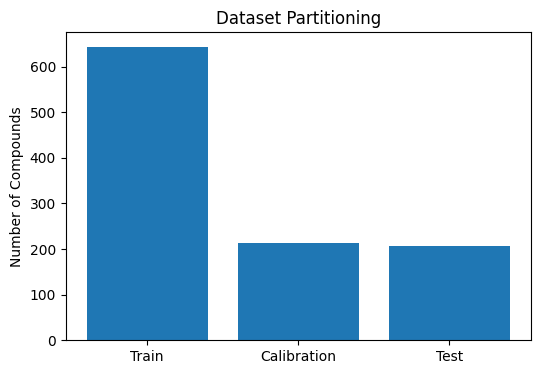

In [7]:
splits = [
    len(train_compounds),
    len(cal_compounds),
    len(test_compounds)
]

plt.figure(figsize=(6,4))
plt.bar(
    ["Train", "Calibration", "Test"],
    splits
)

plt.ylabel("Number of Compounds")
plt.title("Dataset Partitioning")
plt.show()


In [8]:
X_train = physchem_properties.loc[train_compounds, :]
X_cal = physchem_properties.loc[cal_compounds, :]
X_test = physchem_properties.loc[test_compounds, :]

## Conformal Prediction for Classification

We load the binary response (1: 'toxic', 0: 'non-toxic') and separate into training, calibration, and test set.

In [9]:
binary_response = pd.read_csv('../data/binary_response.tsv', sep = '\t', index_col=0)
y_train = binary_response.loc[train_compounds, :]
y_test = binary_response.loc[test_compounds, :]
y_cal = binary_response.loc[cal_compounds, :]

### Random Forest Classifier

A Random Forest (RF) is an ensemble method that combines many decision trees.

Advantages:

- Handles high-dimensional descriptor spaces well.
- Captures nonlinear relationships.
- Robust to noisy descriptors.
- Provides class probabilities that can be used by conformal prediction.

The model is trained only on the training set.

In [10]:
rfc = RandomForestClassifier(n_estimators=500, max_depth=20, min_samples_leaf=15, random_state=42, class_weight='balanced')

In [11]:
rfc.fit(X_train, y_train)

,n_estimators,500
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,15
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Calibration

After training, predictions are generated for the calibration dataset.

For every calibration sample, we compute a (non-)conformity score
that measures how compatible the observed class is with the model prediction. In our case, we compute a non-conformity score, which is called true class ($TC$) score, and that measures the probability of being wrong for a particular sample.

These non-conformity scores form an empirical reference distribution.

The conformal threshold ($\hat{q}$) is derived from the empirical quantile of this distribution
and determines how prediction sets are constructed for unseen compounds. For a given certainty $\alpha$, the empirical $\alpha$-quantile $\hat{q}_{\alpha}$ is defined using the number of calibration samples $n$:

$\hat{q}_{\alpha} = \frac{\lceil(n+1)* \alpha\rceil}{n} $

#### Intuition behind the CP Sets

The RF produces a probability for each class. Rather than directly using these probabilities as confidence estimates, we define a *non-conformity score* as the probability that a prediction is wrong.

For a given sample \(x_i\), the non-conformity score is based on the true class $c_i$ and its corresponding prediction probability \(P(c_i)\)

$TC({x_i}) = 1 - P(c_i)$


A low score corresponds to being correct with a high probability, while a high score means that the model was wrong with a high probability.

During calibration, we determine a threshold ($\hat{q}$) corresponding to the maximum probability of the prediction being wrong that can be tolerated while still achieving the desired coverage guarantee. This threshold is estimated from the calibration set and represents the largest non-conformity score that is acceptable for a prediction to be considered reliable.

In [12]:
certainty = 0.95
true_class_scores = get_pred_score_true_class(estimator=rfc, X=X_cal, y=y_cal.values, minimal_certainty=certainty, class_names=[0,1])

In [13]:
n = len(cal_compounds)
q_class = np.quantile(true_class_scores, math.ceil((n+1)*certainty)/n)

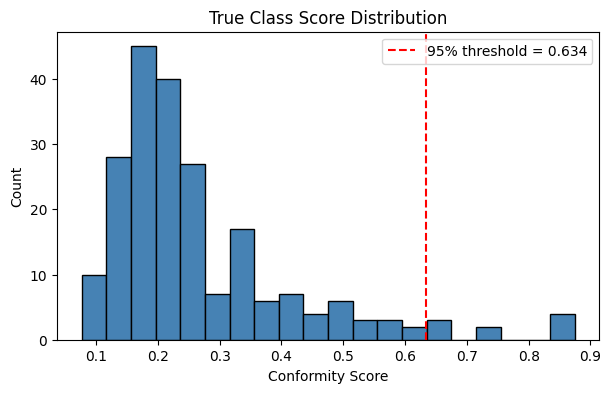

In [14]:
plt.figure(figsize=(7,4))

plt.hist(
    true_class_scores,
    bins=20,
    color="steelblue",
    edgecolor="black"
)

plt.axvline(
    q_class,
    color="red",
    linestyle="--",
    label=f"95% threshold = {q_class:.3f}"
)

plt.xlabel("Conformity Score")
plt.ylabel("Count")
plt.title("True Class Score Distribution")
plt.legend()
plt.show()

### Test predictions

For a new compound, we construct the conformal prediction set by including every class whose non-conformity score is below this threshold:

$\{ c : 1-\hat{P}(c) \le \hat{q}_{\alpha} \}$

Intuitively, this means:

- Classes with a sufficiently low probability of being wrong are retained.
- Classes with a probability of being wrong that exceeds the calibrated threshold are excluded.
- If only one class satisfies the criterion, a singleton prediction set is produced.
- If multiple classes satisfy the criterion, the model expresses uncertainty by returning all plausible classes.
- In rare cases no class may satisfy the criterion, resulting in an empty prediction set.

The threshold is chosen such that, on average, the true class will be retained in the prediction set with the specified coverage level (e.g. 95%). Therefore, conformal prediction does not aim to identify the single most likely class. Instead, it identifies all classes whose probability of being wrong is sufficiently small to maintain the desired statistical guarantee.


As we consider binary classification, prediction sets can have three outcomes:

- Size 0 (only possible if $\hat{q} < 0.5$):
  insufficient support

- Size 1:
  confident prediction

- Size 2 (only possible if $\hat{q} >= 0.5$):
  ambiguous prediction; both classes remain plausible

The more single-class sets are output, i.e., prediction sets containing exactly one class, the more certain is the model, and the more _efficient_ is the CP score.

#### Efficiency 
In classification, efficiency is commonly quantified as the fraction of single-class prediction sets over all predictions.

An efficient conformal predictor produces many single-class predictions while still maintaining the desired certainty guarantee, i.e., _coverage_. Prediction sets containing multiple classes indicate uncertainty and are, therefore, less informative.

In [15]:
test_predictions = rfc.predict_proba(X_test)

In [16]:
results = eval_classification_true_class(y_pred_proba=test_predictions, y_test=y_test.values.flatten(), sample_names=y_test.index, minimal_certainty=certainty, q = q_class, num_classes=2, class_names=[0,1])

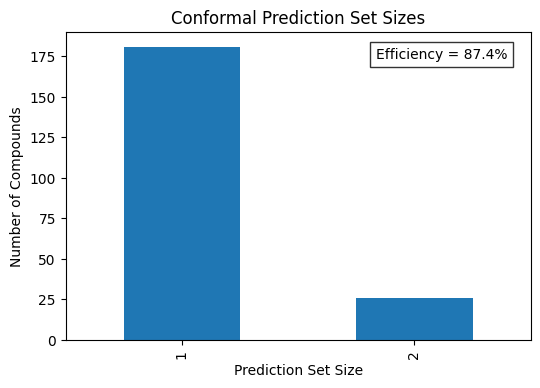

In [17]:
prediction_set_sizes = (
    results["conformal_prediction_95_quantile"]
    .apply(len)
)

ax = prediction_set_sizes.value_counts().sort_index().plot(
    kind="bar",
    figsize=(6,4)
)

# efficiency = fraction of singleton prediction sets
singleton_ratio = len(prediction_set_sizes.loc[prediction_set_sizes == 1])/len(prediction_set_sizes)

ax.text(
    0.95, 0.95,
    f"Efficiency = {singleton_ratio:.1%}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    bbox=dict(
        facecolor="white",
        edgecolor="black",
        alpha=0.8
    )
)

plt.xlabel("Prediction Set Size")
plt.ylabel("Number of Compounds")
plt.title("Conformal Prediction Set Sizes")
plt.show()


#### Coverage

Coverage measures the validity of the conformal predictor. A prediction is considered covered if the true class is contained within the conformal prediction set. For example, if the prediction set is [0, 1], both classes are considered plausible and the prediction is counted as covered regardless of the true outcome.

The empirical coverage is calculated as the proportion of test compounds whose true label is included in the corresponding conformal prediction set. For a conformal predictor with a minimal certainty level of 95%, the empirical coverage should be close to or above 95%, demonstrating that the uncertainty estimates are well calibrated.

High coverage indicates that the conformal prediction sets reliably contain the true class, while lower-than-expected coverage may suggest violations of the assumptions underlying conformal prediction or insufficient calibration data.

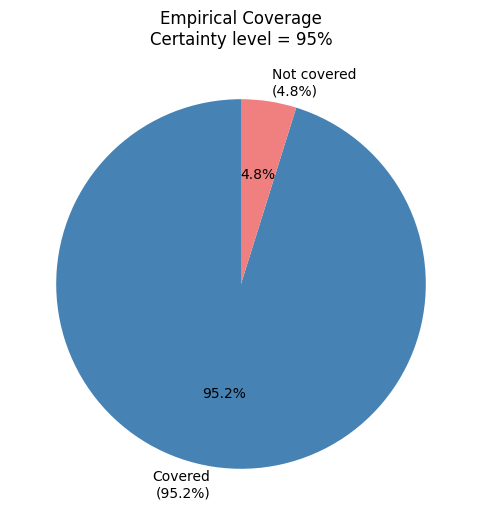

In [18]:
cp_sets = results["conformal_prediction_95_quantile"]

coverage = np.mean([
    y in pred_set
    for y, pred_set in zip(
        results["actual"],
        cp_sets
    )
])

not_covered = 1 - coverage

fig, ax = plt.subplots(figsize=(6,6))

ax.pie(
    [coverage, not_covered],
    labels=[
        f"Covered\n({coverage:.1%})",
        f"Not covered\n({not_covered:.1%})"
    ],
    colors=["steelblue", "lightcoral"],
    autopct="%1.1f%%",
    startangle=90
)

ax.set_title(
    f"Empirical Coverage\nCertainty level = {certainty:.0%}"
)

plt.show()

## Conformal Prediction for Regression

For regression, CP enables us to predict intervals that fulfil the marginal coverage guarantee. Similar to the size of the predicted sets in classification, the size of the predicted intervals in regression corresponds to the model uncertainty. It is desirable that the predicted intervals are relatively small with respect to the spanned training range. The general steps of the CP framework are the same as described above, i.e., we first fit the model, then generate a distribution of the non-conformity scores, which is used to derive a quantile $\hat{q}_{\alpha}$ that we finally use for the prediction. However, in contrast to classification, we cannot base the score on class probabilities and we are going to construct intervals instead of sets.

We use the same compounds as before. The only difference is that we quantify toxicity as a continuous variable instead of a binary label. Thus, we do not need to read and process the SMILES again, but we only read the continuous toxicity values ranging from -1 to 1, where a higher value means higher toxicity.

In [19]:
binary_response = pd.read_csv('../data/continuous_response.tsv', sep = '\t', index_col=0)
y_train = binary_response.loc[train_compounds, :]
y_test = binary_response.loc[test_compounds, :]
y_cal = binary_response.loc[cal_compounds, :]

The non-conformity score that we consider for calibration is based on quantile regression. In contrast to ordinary regression that aims to minimize the distance to the data points, a quantile regressor $f_{\gamma}$, aims to estimate a curve such that for a given quantile $ \gamma \in [0, 1]$, around $\gamma · n$ of the $n$ data points are below the curve and the remaining $∼ (1− \gamma) ·n$ are above. Since the scikit-learn Random Forest Regressor does not support quantile regression, we use our own quantile regression implementation from the `morgoth` package that is based on the algorithm by [Meinshausen](https://www.jmlr.org/papers/volume7/meinshausen06a/meinshausen06a.pdf). 

In [20]:
output_dir = '../data/morgoth_output/'
morgoth_regression_model = MORGOTH(X_train=X_train, 
        y_train=y_train['activity'].values, 
        criterion_class=None, 
        criterion_reg='mse', 
        sample_names_train=train_compounds, 
        min_number_of_samples_per_leaf=15, 
        number_of_features_per_split = 'sqrt', 
        number_of_trees_in_forest=100, 
        class_names=None,
        output_format='regression',
        threshold=None,
        max_depth=20, 
        impact_classification=0,
        sample_weights_included=None,
        random_state=42,
        time_file=f'{output_dir}/time_file.txt',
        analysis_name = 'CP_regression',
        sample_info_file = f'{output_dir}/sample_info_file.txt',
        leaf_assignment_file_train = f'{output_dir}/leaf_assignment_file_train.txt',
        feature_imp_output_file = f'{output_dir}/feature_imp_output_file.txt',
)

Your input parameters are: 
Number of trees: 100
Min number of samples per leaf: 15
Number of features per split: sqrt
Maximum depth of the trees: 20
The dimensions of your training matrix are: 
Number of rows (samples): 643
Number of columns (features): 205
no sample weights


In [21]:
morgoth_regression_model.fit()

average time for a tree: 125.43828643952995
forest grown in 615.6446302690001 seconds.


## Calibration

Using quantile regression, we can calculate an upper and a lower bound for the interval by casting two quantile predictions. To obtain an interval that covers samples with a probability of approximately $\alpha$, design the quantiles so that $\frac{1-\alpha}{2}$ of the samples lie below and above the curves, respectively. Thus, we perform a quantile regression for $ \frac{(1 - \alpha)}{2}$ (lower bound) and $1- \frac{(1 - \alpha)}{2}$ (upper bound). If the estimation of the conditional distribution function would be accurate, we would expect that the fraction of samples that are inside the interval given by 

$[ \hat{f}_{\frac{1-\alpha}{2}}, \hat{f}_{1-\frac{1-\alpha}{2}}]$

is approximately $\alpha$.

In [22]:
uncertainty_level = 1-certainty
quantile_predictions = morgoth_regression_model.predict(X_cal, quantile=[uncertainty_level/2, 1-(uncertainty_level/2)])

no distance measure given


In [23]:
quantile_predictions= quantile_predictions.astype(float)

In [24]:
lower = quantile_predictions[:, 0]
upper = quantile_predictions[:, 1]

For regression, we use a score, which is the signed distance between the actual response $y_i$ for a sample $x_i$ and the closest interval boundary. It will be positive if the sample is either above the higher interval boundary or below the lower one, i.e., if the true response is outside the interval. Calculating this score for all samples in the calibration dataset, we, again, observe a distribution of scores. Intuitively, we would like the prediction intervals to be as small as possible while guaranteeing the certainty level, because then, we could know the true value (range) relatively exact with a probability of our desired certainty level.

In [25]:
quantile_regression_scores = get_pred_score_regression(minimal_certainty=certainty, 
                          X=X_cal, y = y_cal['activity'].values, 
                          p_upper=upper, p_lower=lower)

In [26]:
n = len(cal_compounds)
q_reg = np.quantile(quantile_regression_scores, math.ceil((n+1)*certainty)/n)

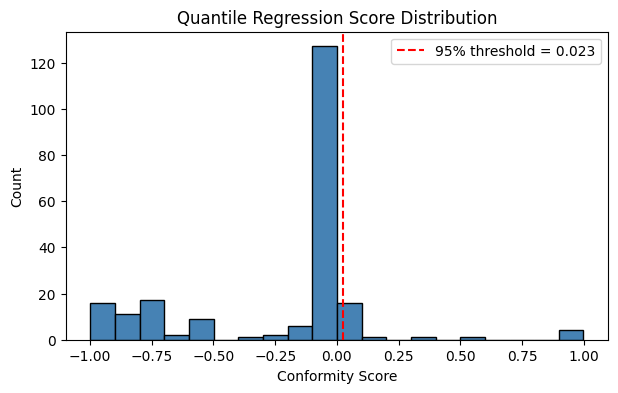

In [27]:
plt.figure(figsize=(7,4))

plt.hist(
    quantile_regression_scores,
    bins=20,
    color="steelblue",
    edgecolor="black"
)

plt.axvline(
    q_reg,
    color="red",
    linestyle="--",
    label=f"95% threshold = {q_reg:.3f}"
)

plt.xlabel("Conformity Score")
plt.ylabel("Count")
plt.title("Quantile Regression Score Distribution")
plt.legend()
plt.show()

If $\hat{q}_{\alpha}$ is positive, the intervals defined by quantile regression are too narrow and need to be widened to fulfil the coverage guarantee. If q is negative, we can narrow the intervals, leading to more precise predictions. Thus, the prediction interval $\hat{y}_i$ for a sample $x_i$ is given by:

$\hat{y}_i = [f_{\frac{(1-\alpha)}{2}}(x_i) - \hat{q}_{\alpha}, f_{1-\frac{(1-\alpha)}{2}}(x_i) + \hat{q}_{\alpha} ] $


In [28]:
test_predictions = morgoth_regression_model.predict(X_test, quantile=[uncertainty_level/2, 1-(uncertainty_level/2)])

no distance measure given


In [29]:
regression_results = eval_regression(predictions = test_predictions, true_y = y_test['activity'].values, 
                sample_names=test_compounds, minimal_certainty=certainty, q=q_reg)

### Coverage

For regression, we can also calculate the coverage as the fraction of samples, where the true response is inside the interval boundaries.

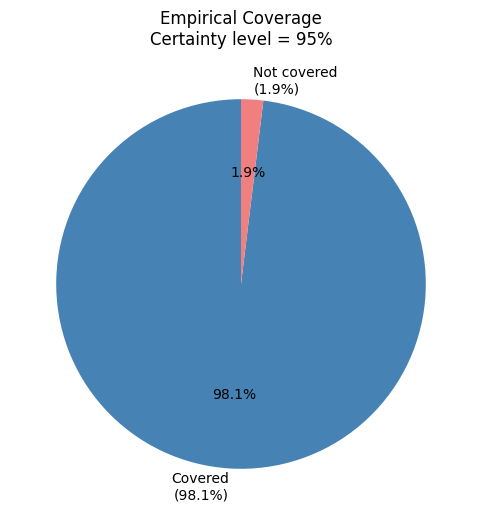

In [30]:
# Fraction of samples whose actual value lies within the prediction interval

coverage = regression_results["actual_in_interval"].mean()
not_covered = 1 - coverage

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie([coverage, not_covered],
labels=[
f"Covered\n({coverage:.1%})",
f"Not covered\n({not_covered:.1%})"
],

colors=["steelblue", "lightcoral"],

autopct="%1.1f%%",

startangle=90
)


ax.set_title(
f"Empirical Coverage\nCertainty level = {certainty:.0%}"
)

plt.show()

## Efficiency

For regression, efficiency is associated with the size of the intervals. Therefore, we now calculate the interval size relative to the spanned range of values [-1,1].

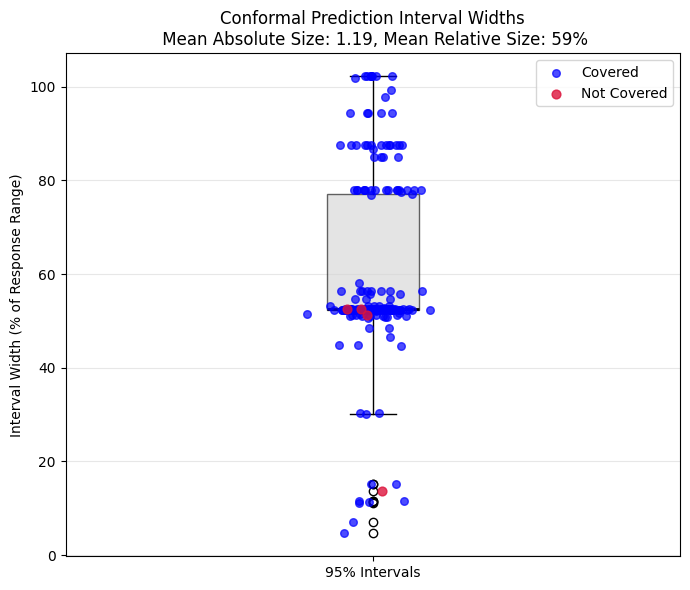

In [31]:
# Interval widths
interval_sizes = (
    regression_results["conformal_prediction_95_quantile_upper"]
    - regression_results["conformal_prediction_95_quantile_lower"]
)

# Relative width (% of response range [-1, 1])
relative_width_pct = 100 * interval_sizes / 2

covered = regression_results["actual_in_interval"].to_numpy(dtype=bool)

plt.figure(figsize=(7, 6))

# Boxplot
plt.boxplot(
    relative_width_pct,
    patch_artist=True,
    boxprops=dict(facecolor="lightgray", alpha=0.6),
    medianprops=dict(color="black", linewidth=2)
)

# Jittered x-positions
x_jitter = np.random.normal(1, 0.03, len(relative_width_pct))

# Covered points
plt.scatter(
    x_jitter[covered],
    relative_width_pct[covered],
    color="blue",
    alpha=0.7,
    s=30,
    label="Covered",
    zorder=3
)

# Not-covered points
plt.scatter(
    x_jitter[~covered],
    relative_width_pct[~covered],
    color="crimson",
    alpha=0.8,
    s=40,
    label="Not Covered",
    zorder=3
)

plt.ylabel("Interval Width (% of Response Range)")
plt.title(f"Conformal Prediction Interval Widths\n Mean Absolute Size: {np.mean(interval_sizes):.3}, Mean Relative Size: {round((np.mean(interval_sizes)/2)*100)}%")
plt.xticks([1], ["95% Intervals"])
plt.grid(axis="y", alpha=0.3)
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

Moreover, we now show a scatter plot with the true responses and the intervals around them.

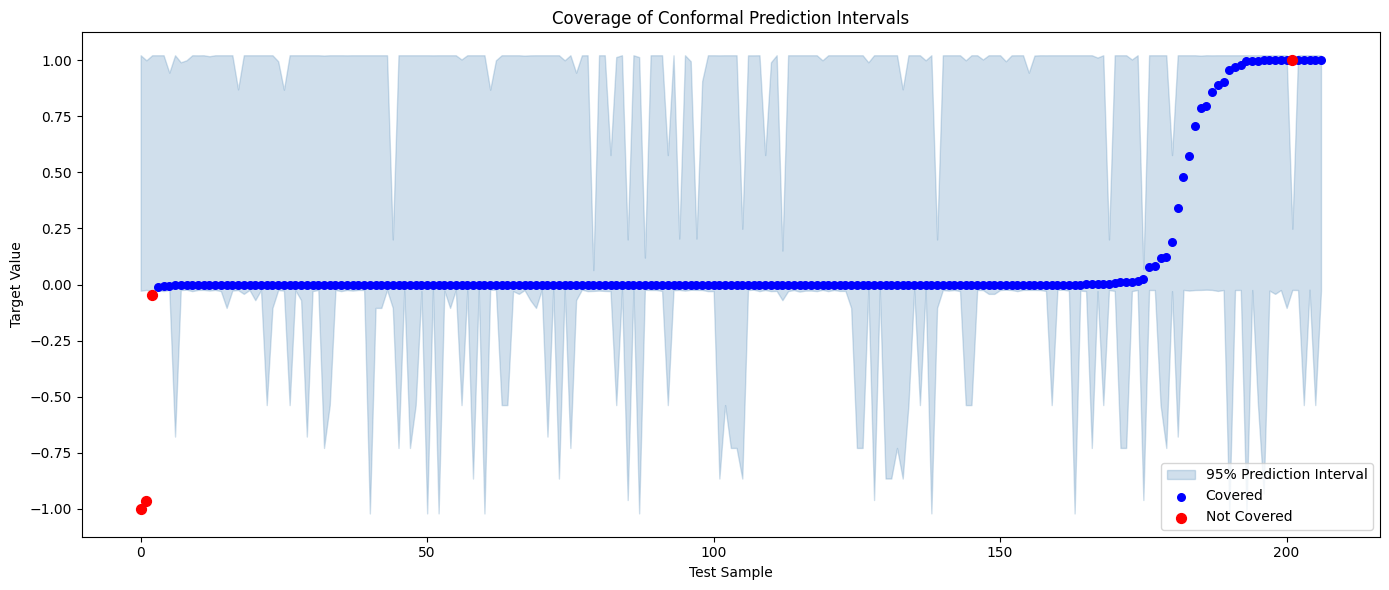

In [32]:
regression_results.sort_values("actual", inplace=True)
x = np.arange(len(regression_results))

plt.figure(figsize=(14, 6))

plt.fill_between(
    x,
    regression_results["conformal_prediction_95_quantile_lower"].astype(float).values,
    regression_results["conformal_prediction_95_quantile_upper"].astype(float).values,
    color="steelblue",
    alpha=0.25,
    label="95% Prediction Interval"
)

covered = regression_results["actual_in_interval"].to_numpy(dtype=bool)
not_covered = ~covered

plt.scatter(
    x[covered],
    regression_results.loc[covered, "actual"],
    color="blue",
    s=30,
    label="Covered"
)

plt.scatter(
    x[not_covered],
    regression_results.loc[not_covered, "actual"],
    color="red",
    s=50,
    label="Not Covered"
)

plt.xlabel("Test Sample")
plt.ylabel("Target Value")
plt.title("Coverage of Conformal Prediction Intervals")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Conclusions

Inductive CP converts the notion of uncertainty (i.e., prediction probabilities for classification and quantiles for regression) into statistically
valid prediction sets (classification) or intervals (regression) by calibrating uncertainty on an independent calibration set.

Benefits:

- Rigorous coverage guarantees.
- Explicit uncertainty quantification.
- Improved reliability compared with raw probabilities.

Limitations:

- Requires a dedicated calibration set.
- Larger uncertainty leads to less specific predictions.
- Not really suited for small datasets $\rightarrow$ transductive CP is needed

Overall, CP provides a practical framework for deploying trustworthy
machine learning models in computational biology, chemistry, medicine, or pharmacy.